In [1]:
#STEP-1 IMPORTING LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
#STEP-2 LOAD DATASET
df=pd.read_csv('/content/laptop_price.csv', encoding='latin1')
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [6]:
print(df.columns)

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')


In [13]:
#STEP-3 DATA PREPROCESSING
#1. Converting categorical data to numerical and handling NaNs
# Apply NaN filling strategy: numerical NaNs with mean, categorical NaNs with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Identify actual categorical columns for dummy variable creation
categorical_cols = df.select_dtypes(include='object').columns

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

#2. Feature Selection
#Separate features and target variable
X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

# Spliting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#STEP-4 TRAIN-TEST SPLIT
#Spliting the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
print(df.columns)

Index(['laptop_ID', 'Inches', 'Ram', 'Weight', 'Price_euros', 'Company_Apple',
       'Company_Asus', 'Company_Chuwi', 'Company_Dell', 'Company_Fujitsu',
       ...
       'Gpu_Nvidia Quadro M620', 'Gpu_Nvidia Quadro M620M', 'OpSys_Chrome OS',
       'OpSys_Linux', 'OpSys_Mac OS X', 'OpSys_No OS', 'OpSys_Windows 10',
       'OpSys_Windows 10 S', 'OpSys_Windows 7', 'OpSys_macOS'],
      dtype='object', length=956)


In [16]:
#STEP-5 TRAIN MODEL
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)

#STEP-6 MAKE PREDICTIONS
y_pred = linear_regressor.predict(X_test)
print("predictions",y_pred)

#STEP-7 EVALUATE THE MODEL
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

predictions [1347.93050716 1007.26127274  903.88199254  913.03721313 1438.48509468
 1218.97829041  574.47643545  589.20538698 1622.38640005  488.32724035
 1841.53545501  734.72972907 2072.20296687  771.63139564 1815.08366749
 1105.07479632 1201.8411983   691.16939131  945.60046975 1735.20639677
 1161.38330176  722.4529183  1150.5703685   599.38431111  843.44011147
 1228.46224432  920.28215071  947.05066831 1930.20071403 1050.92313115
  550.34092018 1570.32167314 1951.30340053  892.48542872  964.6666285
  797.95403558  756.86967363  745.24833838 1329.98360797  300.04964717
 2092.15780652  639.5459495   836.83072085 3139.79068375  607.28508914
 1003.51746446 1273.03685295  400.71377997  921.22365485 1641.80645464
 1776.33460406 1156.80873776 1111.65225096 1388.5757999   682.42791454
 1227.62092384  485.42110668  779.57675389  783.07598553  914.45915866
 1912.27214049  942.23185574  610.6388838   652.86855971  304.20899374
 2165.32076706  808.91431719  898.91674955  542.45380803 1306.8327

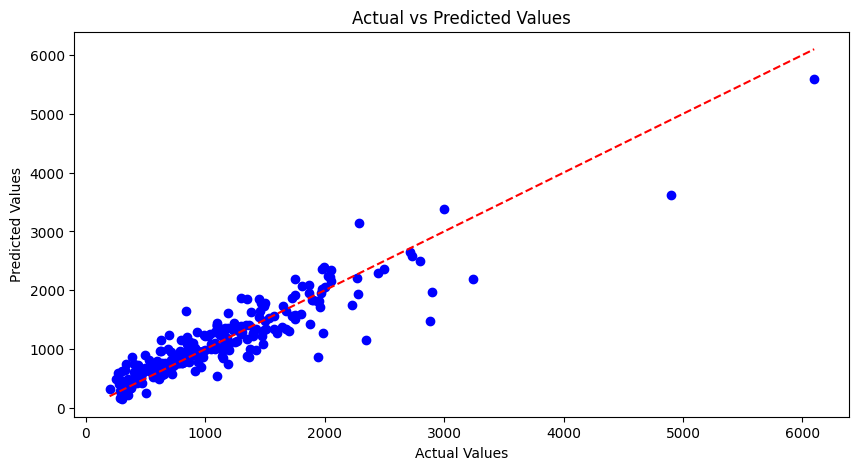

In [17]:
#STEP-8 VISUALIZING THE RESULTS
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/content/laptop_price.csv', encoding='latin1')

# Clean 'Ram' and 'Weight' columns
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# Apply NaN filling strategy: numerical NaNs with mean, categorical NaNs with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Identify actual categorical columns for dummy variable creation
categorical_cols = df.select_dtypes(include='object').columns

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('Price_euros', axis=1)
y = df['Price_euros']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#To fit and evaluate Decision Tree Regressor
dtree = DecisionTreeRegressor()
dtree.fit(X_train, y_train)
y_pred_dtree = dtree.predict(X_test)
print("Predictions:", y_pred_dtree)

#To fit and evaluate Random Forest Regressor
rf_regressor = RandomForestRegressor(n_estimators=50, random_state=42)
rf_regressor.fit(X_train, y_train)
y_pred_rf = rf_regressor.predict(X_test)
print("Predictions:", y_pred_rf)

# Evaluation metrics
mse_dtree = mean_squared_error(y_test, y_pred_dtree)
r2_dtree = r2_score(y_test, y_pred_dtree)

mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Printing evaluation results
print("Decision Tree Regressor:")
print("Mean Squared Error:", mse_dtree)
print("R² Score:", r2_dtree)
print("\nRandom Forest Regressor:")
print("Mean Squared Error:", mse_rf)
print("R² Score:", r2_rf)

Predictions: [1010.   1650.    577.    899.   1195.   1499.    705.5   849.   1249.
  447.   1199.    955.    989.    805.99 1598.    884.   1399.    906.62
  659.   1859.   2758.    720.32 1669.    419.    879.    949.    849.
  485.   2559.    935.    459.   2089.   1483.    819.    860.    850.66
  499.    572.   1169.    249.   1799.    849.    663.   2505.02  617.9
  945.   1607.96  249.    719.   1379.   1859.    629.    698.    398.99
  799.   1323.    210.8   770.   1213.    899.   1820.   1262.    450.
  754.    288.9  1799.    539.    899.    929.   2799.   3890.    740.
  399.    794.    849.    455.7   699.   1369.   1199.   1349.   1260.
  549.    202.9   810.    286.   1819.    447.   1549.   1149.    813.
 1399.   2663.   1099.    549.   1229.    485.   1119.    850.66  589.52
 1010.51  447.    849.    740.   1825.    935.    805.99 1599.    419.
 1064.    646.27 1600.    879.    999.   2499.    348.   2249.   1599.
 2089.    745.   1142.4  5499.    389.    919.    659. 

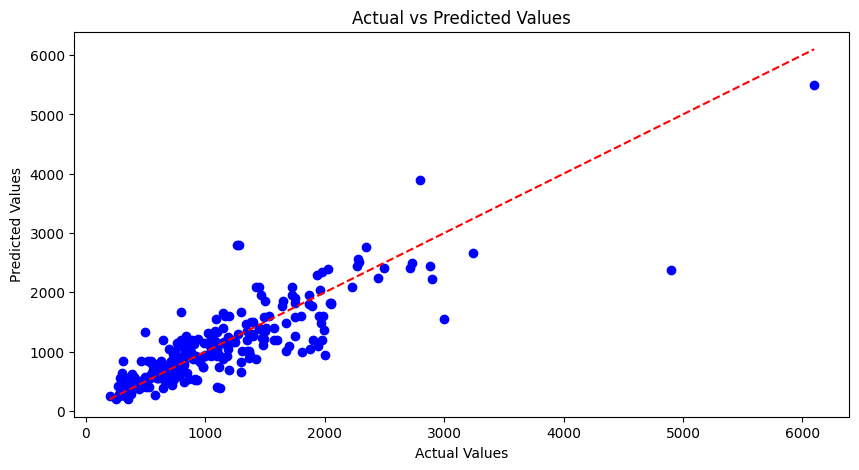

In [22]:
#Visual representation using multiple plots for implementation of the decision tree and random forest
#1. SCATTER PLOT
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred_dtree, color='blue')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

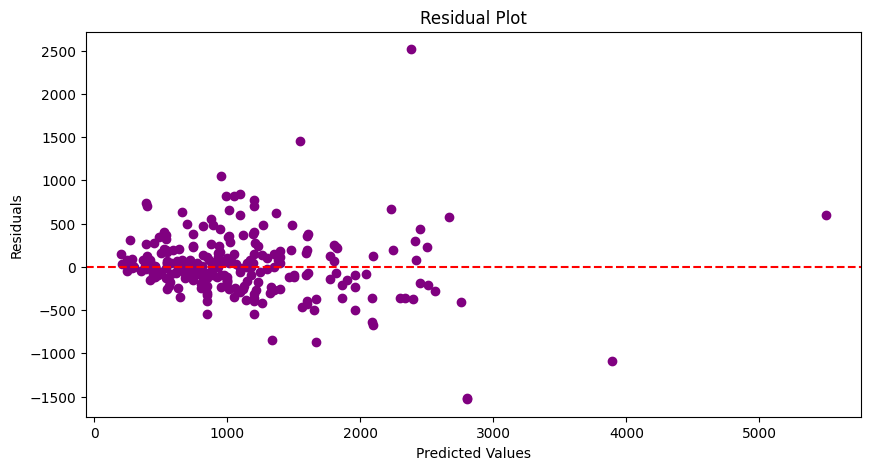

In [24]:
#2.RESIDUAL PLOT
residuals = y_test - y_pred_dtree
plt.figure(figsize=(10, 5))
plt.scatter(y_pred_dtree, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [26]:
#IMPLEMENTATION OF XGBOOST
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('/content/laptop_price.csv', encoding='latin1')

# Clean 'Ram' and 'Weight' columns
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

# Apply NaN filling strategy: numerical NaNs with mean, categorical NaNs with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Identify actual categorical columns for dummy variable creation
categorical_cols = df.select_dtypes(include='object').columns

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop('Price_euros', axis=1)
y = df['Price_euros']

# Fix column names for XGBoost compatibility
X.columns = [str(col).replace("[", "").replace("]", "").replace("<", "").replace(">", "") for col in X.columns]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit and evaluate XGBoost Regressor
xgboost_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgboost_model.fit(X_train, y_train)
y_pred_xgb = xgboost_model.predict(X_test)

# Evaluation metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print evaluation results
print("XGBoost Regressor predictions:",y_pred_xgb)
print("Mean Squared Error:", mse_xgb)
print("R² Score:", r2_xgb)

XGBoost Regressor predictions: [1204.67    1347.9363   501.63113  708.1545  1136.7362  1205.7021
  665.8037   671.7282  1229.9911   461.00037 1997.4979   711.3944
 1494.9735   656.1454  1840.3134   963.85693 1471.5297   781.51544
  688.85187 1833.2012  2453.9297   547.26056 1333.1359   407.51868
  966.2313  1156.5349   673.3763   696.0551  1978.7847  1011.1076
  525.5882  1695.1001  1646.1523  1296.0054   967.0123   686.5168
  650.6075   574.09106 1185.2413   316.68073 1669.2761   682.0694
 1010.0616  2342.648    602.9552   989.9225  1624.8715   291.05627
  954.43854 1499.0914  1643.1646   774.6321   726.9666   784.5515
  716.903   1569.1771   291.22574  883.1126   903.9515   708.1545
 2186.1426   815.90295  392.29883  645.22363  369.7341  1912.9003
  565.5231  1022.4869  1215.9518  3332.242   3278.3625  1053.2803
  437.9674   767.37213  387.75113  442.3695   751.8684  1691.7937
 1434.7577  1476.2529  1507.0934   505.8155   234.87218  872.72955
  337.00546 1692.4161   556.6887  2480.58

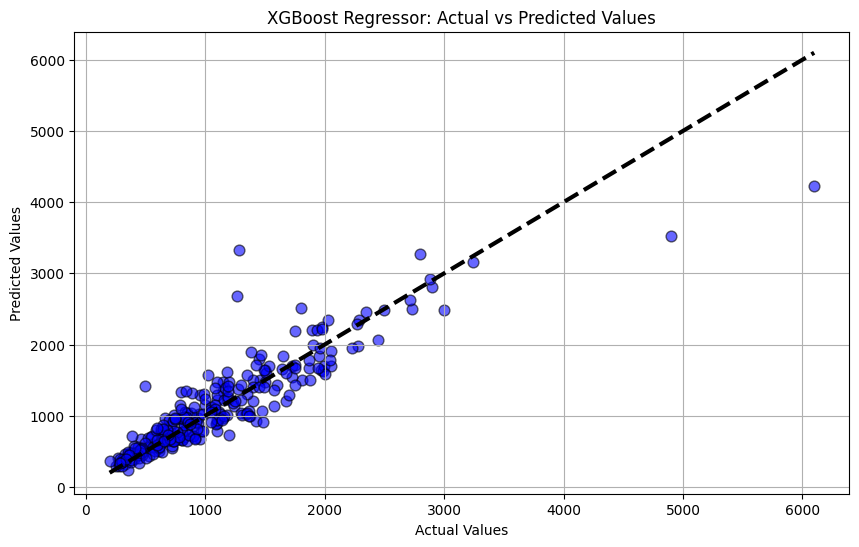

In [27]:
#Visual representation using scatter plot for implementation of the XGBOOST
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_xgb, color='blue', edgecolor='k', alpha=0.6, s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=3)  # Line of perfect prediction
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost Regressor: Actual vs Predicted Values')
plt.grid(True)
plt.show()

In [8]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   int64  
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   float64
 12  Price_euros       1303 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 132.5+ KB
None
   laptop_ID Company      Product   TypeName  Inches  \
0          1   Apple  MacBook Pro  Ultrabook    13.3   
1      